# RealWaste CNN Classification Notebook

This notebook is designed for your **waste classification final project** and is meant to be both:

1. a **strong training notebook** focused on **high classification accuracy**, and  
2. a **learning notebook** that explains *why* each step exists so you can use it in your report and presentation.

---

## Project goals

We want to:
- classify waste images from the **RealWaste** dataset,
- compare several CNN backbones,
- improve accuracy with transfer learning, augmentation, and tuning,
- keep careful notes about what helped and what did not,
- prepare the project for a later upgrade to **YOLO/object detection**.

---

## Why this notebook is different from the earlier notebooks

The sample notebooks were useful starting points, but for this project we want a more rigorous pipeline:

- **stratified train/validation/test split** instead of a plain random split,
- **clear experiment tracking** so you can report results,
- **modern pretrained CNN backbones** instead of training from scratch,
- **stronger data augmentation** because the dataset is relatively small,
- **class imbalance handling** because some classes have many more images than others,
- **confusion matrix and per-class metrics** so we can see exactly where mistakes happen.

This notebook is written step by step so you can learn as you go.

## Recommended workflow for the project

### Phase 1: Strong image classifier first
Start with image classification using one object per image. This is the fastest way to get a high-quality baseline and learn the dataset.

### Phase 2: Improve accuracy carefully
We will test changes one at a time:
- augmentation,
- image size,
- class weighting,
- better pretrained backbones,
- learning-rate scheduling,
- freezing vs. unfreezing layers,
- optional MixUp / CutMix.

### Phase 3: Transition to YOLO later
YOLO is for **object detection**, not just classification. That means you will need:
- bounding boxes,
- possibly multiple objects per image,
- a different dataset format.

So the right order is:
**classification first -> understand class confusion -> then build object detection**.

## Environment setup

Create a virtual environment first, then install the packages you need.

Example:

```bash
python -m venv .venv
source .venv/bin/activate        # macOS/Linux
# .venv\Scriptsctivate         # Windows

pip install --upgrade pip
pip install torch torchvision torchaudio
pip install scikit-learn pandas matplotlib seaborn pillow tqdm
```

Optional later:

```bash
pip install jupyterlab
pip install ultralytics   # for YOLO later
```

If you are using Apple Silicon (M1/M2/M3), this notebook can also use **MPS**.

In [ ]:

# If you need to install packages inside the notebook, uncomment these lines:
# %pip install torch torchvision torchaudio scikit-learn pandas matplotlib seaborn pillow tqdm

## 1. Imports and configuration

We keep most project settings in one place so it is easy to change things later and easy to explain in your report.

In [1]:

import os
import copy
import json
import math
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    resnet50, ResNet50_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    efficientnet_b2, EfficientNet_B2_Weights,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from tqdm.auto import tqdm

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## 2. Reproducibility and device

Why this matters:
- Reproducibility makes experiments fair.
- Device detection lets the notebook work on CPU, CUDA GPU, or Apple MPS.

In [2]:

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

Using device: mps


## 3. Set your dataset path

This notebook assumes the dataset is arranged like this:

```text
RealWaste/
    Cardboard/
    FoodOrganics/
    Glass/
    Metal/
    MiscellaneousTrash/
    Paper/
    Plastic/
    TextileTrash/
    Vegetation/
```

If your folder names are slightly different, that is okay. The notebook will read class names from the directory structure.

In [4]:

# CHANGE THIS to wherever your RealWaste dataset is stored.
DATA_DIR = Path("./RealWaste")

assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR.resolve()}"
print("Dataset directory:", DATA_DIR.resolve())

Dataset directory: /Users/juliareinhart/Documents/CSCI611AppliedMachineLearning/BranchJuliaFinalProject/RealWaste


## 4. Build a dataframe of file paths and labels

Why do this instead of relying only on `ImageFolder`?

Because it gives us more control:
- we can make a **stratified split**,
- inspect class imbalance,
- save file-based train/val/test splits for reproducibility,
- later reuse the same split for future models.

In [5]:

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []
for class_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    for img_path in sorted(class_dir.rglob("*")):
        if img_path.suffix.lower() in IMG_EXTS:
            records.append({"filepath": str(img_path), "label": class_dir.name})

_df = pd.DataFrame(records)
assert len(_df) > 0, "No images found. Check DATA_DIR and folder structure."

print(f"Total images found: {len(_df):,}")
display(_df.head())

Total images found: 4,752


,filepath,label
0,RealWaste/Cardboard/Cardboard_1.jpg,Cardboard
1,RealWaste/Cardboard/Cardboard_10.jpg,Cardboard
2,RealWaste/Cardboard/Cardboard_100.jpg,Cardboard
3,RealWaste/Cardboard/Cardboard_101.jpg,Cardboard
4,RealWaste/Cardboard/Cardboard_102.jpg,Cardboard


## 5. Inspect class balance

This is important because your dataset is **not perfectly balanced**.

That matters because a model can look "good" overall while still doing poorly on smaller classes.

,count
label,
Cardboard,461
Food Organics,411
Glass,420
Metal,790
Miscellaneous Trash,495
Paper,500
Plastic,921
Textile Trash,318
Vegetation,436


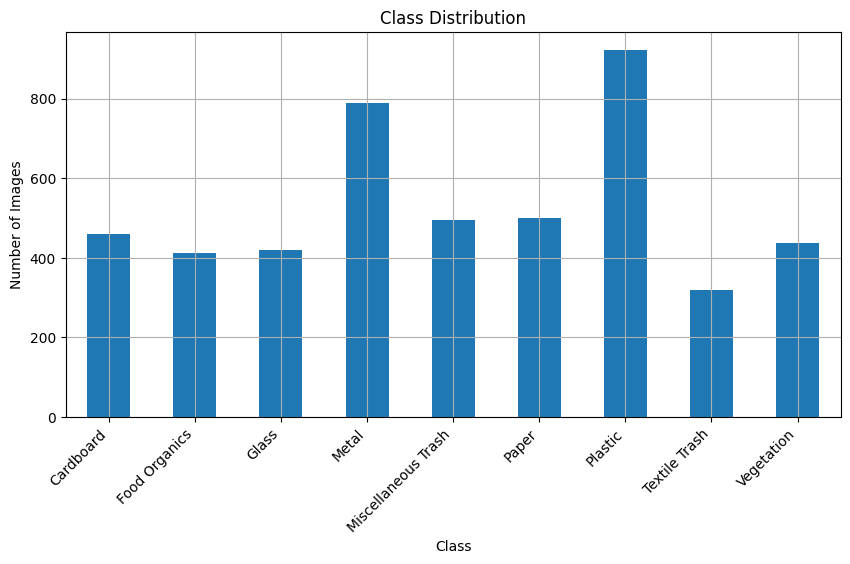

In [6]:

class_counts = _df['label'].value_counts().sort_index()
display(class_counts.to_frame(name='count'))

plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.show()

### Notes for your report

You can say something like:

- The dataset is moderately imbalanced.
- Plastic and Metal have many more samples than Textile Trash or Food Organics.
- This motivates using **class weighting** and/or **weighted sampling** during training.

## 6. Stratified train / validation / test split

This is one of the most important improvements over a plain random split.

A stratified split tries to preserve class proportions across each split.
That gives a **fairer validation set** and **fairer test set**.

In [7]:

train_df, temp_df = train_test_split(
    _df,
    test_size=0.20,
    stratify=_df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED,
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

split_summary = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'val': val_df['label'].value_counts().sort_index(),
    'test': test_df['label'].value_counts().sort_index(),
}).fillna(0).astype(int)
display(split_summary)

Train size: 3801
Val size:   475
Test size:  476


,train,val,test
label,,,
Cardboard,369,46,46
Food Organics,329,41,41
Glass,336,42,42
Metal,632,79,79
Miscellaneous Trash,396,49,50
Paper,400,50,50
Plastic,736,92,93
Textile Trash,254,32,32
Vegetation,349,44,43


In [8]:

# Save the split so future experiments use exactly the same images.
SPLIT_DIR = Path("./splits")
SPLIT_DIR.mkdir(exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train_split.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val_split.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test_split.csv", index=False)

print("Saved split files to:", SPLIT_DIR.resolve())

Saved split files to: /Users/juliareinhart/Documents/CSCI611AppliedMachineLearning/BranchJuliaFinalProject/splits


## 7. Create label mappings

We convert class names into integer indices because models train on numbers, not strings.

In [9]:

class_names = sorted(_df['label'].unique().tolist())
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

print(class_to_idx)
NUM_CLASSES = len(class_names)
print("Number of classes:", NUM_CLASSES)

{'Cardboard': 0, 'Food Organics': 1, 'Glass': 2, 'Metal': 3, 'Miscellaneous Trash': 4, 'Paper': 5, 'Plastic': 6, 'Textile Trash': 7, 'Vegetation': 8}
Number of classes: 9


## 8. Define image transforms

### Why data augmentation matters here

RealWaste is not a huge dataset, so augmentation helps the model see more variety.
This can reduce overfitting and improve generalization.

### Good augmentations for this task

Useful:
- horizontal flip,
- small rotations,
- random resized crop,
- slight color jitter,
- small perspective / affine changes.

Usually avoid extreme transforms that make waste objects unrealistic.

### Important note
Vertical flips are not always ideal for all real-world objects. They can still help sometimes, but I recommend starting with **horizontal flip first** and only adding more aggressive transforms if validation accuracy improves.

In [10]:

# Change image size here if you want to experiment.
# 224 is standard and efficient. 260 or 288 can sometimes help slightly.
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## 9. Custom dataset class using the saved dataframes

In [11]:

class WasteDataset(Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = self.class_to_idx[row['label']]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

## 10. Build datasets and dataloaders

We will use a **WeightedRandomSampler** during training.

### Why this helps
If one class has far fewer samples, the sampler makes it more likely those images still appear often during training.
This is one way to reduce the effect of imbalance.

In [14]:

train_dataset = WasteDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = WasteDataset(val_df, class_to_idx, transform=val_test_transform)
test_dataset = WasteDataset(test_df, class_to_idx, transform=val_test_transform)

train_class_counts = train_df['label'].value_counts().sort_index()
train_sample_weights = train_df['label'].map(lambda x: 1.0 / train_class_counts[x]).values
train_sample_weights = torch.DoubleTensor(train_sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True,
)

BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("Dataloaders ready.")

Dataloaders ready.


## 11. Visualize a few augmented training images

This is important because it lets you check whether the augmentations are helpful or too aggressive.

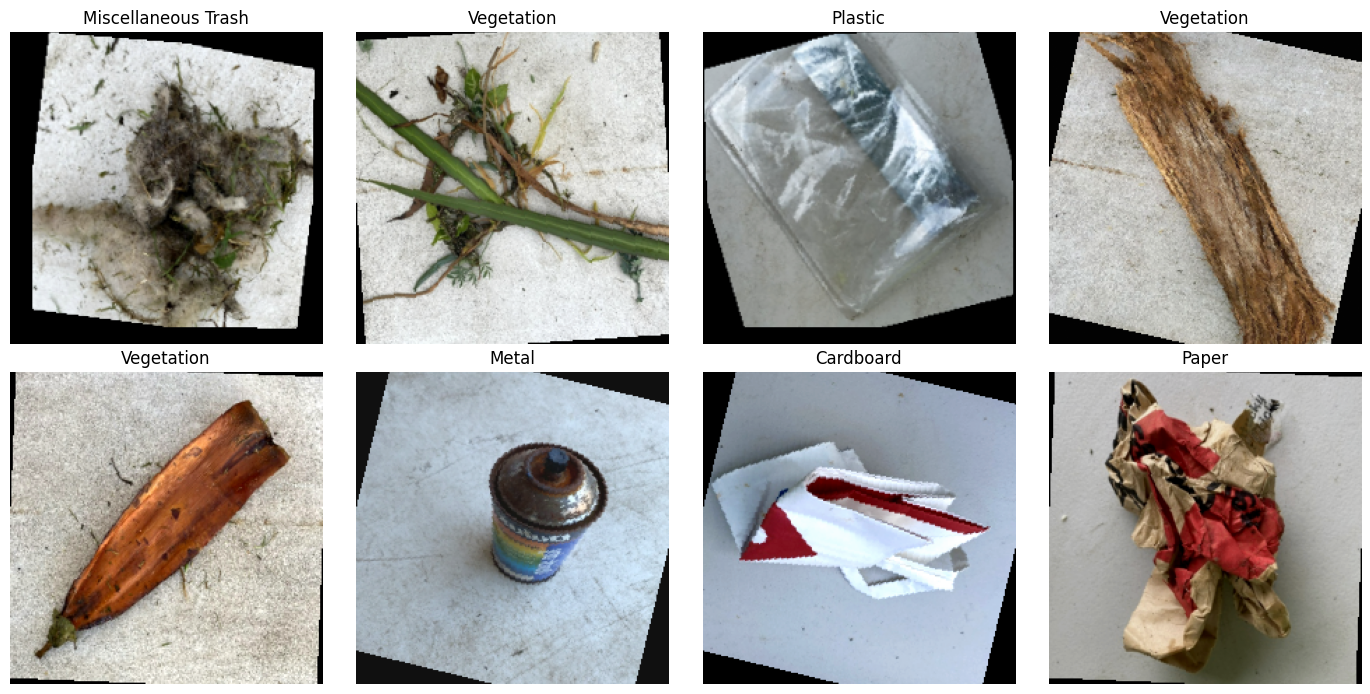

In [15]:

def denormalize(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor.cpu() * std + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for ax, image, label in zip(axes, images[:8], labels[:8]):
    img = denormalize(image).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(idx_to_class[int(label)])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 12. Class weights for the loss function

We are going to combine two ideas:
- **Weighted sampling** to show minority classes more often,
- **Class-weighted loss** so mistakes on minority classes matter more.

This does not always help, but it is a good experiment for an imbalanced dataset.

In [16]:

train_counts_vector = np.array([train_class_counts[name] for name in class_names], dtype=np.float32)
class_weights = train_counts_vector.sum() / (len(train_counts_vector) * train_counts_vector)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Class weights:")
for name, weight in zip(class_names, class_weights.cpu().numpy()):
    print(f"{name:>22}: {weight:.3f}")

Class weights:
             Cardboard: 1.145
         Food Organics: 1.284
                 Glass: 1.257
                 Metal: 0.668
   Miscellaneous Trash: 1.066
                 Paper: 1.056
               Plastic: 0.574
         Textile Trash: 1.663
            Vegetation: 1.210


## 13. Model factory

We will compare several pretrained CNN backbones:
- **ResNet50**
- **MobileNetV3-Large**
- **EfficientNet-B0**
- **EfficientNet-B2**

### Why pretrained models?
They already know useful visual patterns from ImageNet, so they usually perform much better than training from scratch on a small dataset.

### Suggested strategy
1. Train the classifier head first with the backbone frozen.  
2. Then unfreeze the backbone and fine-tune the full network.  

That is usually a strong approach for accuracy on smaller datasets.

In [17]:

def build_model(model_name: str, num_classes: int, freeze_backbone: bool = True):
    model_name = model_name.lower()

    if model_name == 'resnet50':
        weights = ResNet50_Weights.DEFAULT
        model = resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'mobilenet_v3_large':
        weights = MobileNet_V3_Large_Weights.DEFAULT
        model = mobilenet_v3_large(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    elif model_name == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'efficientnet_b2':
        weights = EfficientNet_B2_Weights.DEFAULT
        model = efficientnet_b2(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze only the classifier head
        if model_name == 'resnet50':
            for param in model.fc.parameters():
                param.requires_grad = True
        else:
            for param in model.classifier.parameters():
                param.requires_grad = True

    return model

## 14. Training utilities

This section contains the reusable training loop.

### Accuracy-focused decisions used here
- **CrossEntropyLoss with label smoothing**: often helps generalization.
- **AdamW**: good optimizer for transfer learning.
- **ReduceLROnPlateau** scheduler: lowers learning rate when validation stops improving.
- **Early stopping**: prevents wasting epochs after the model stops improving.
- **Macro F1 score**: useful because the classes are imbalanced.

In [18]:

@dataclass
class TrainConfig:
    model_name: str = 'efficientnet_b2'
    epochs_head: int = 5
    epochs_finetune: int = 12
    lr_head: float = 1e-3
    lr_finetune: float = 2e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    patience: int = 5
    use_class_weights: bool = True


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in tqdm(loader, leave=False):
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in tqdm(loader, leave=False):
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1, np.array(all_targets), np.array(all_preds)

In [19]:

def run_training(config: TrainConfig, train_loader, val_loader, device=DEVICE):
    model = build_model(config.model_name, NUM_CLASSES, freeze_backbone=True).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights if config.use_class_weights else None,
        label_smoothing=config.label_smoothing,
    )

    history = []
    best_state = None
    best_val_f1 = -np.inf
    no_improve_count = 0

    # ---------------------------
    # Phase 1: train classifier head only
    # ---------------------------
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config.lr_head,
        weight_decay=config.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )

    total_epochs = config.epochs_head + config.epochs_finetune

    for epoch in range(1, config.epochs_head + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_f1)

        row = {
            'epoch': epoch,
            'phase': 'head',
            'train_loss': train_loss,
            'train_acc': train_acc,
            'train_f1': train_f1,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)
        print(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

    # ---------------------------
    # Phase 2: fine-tune all layers
    # ---------------------------
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(
        model.parameters(),
        lr=config.lr_finetune,
        weight_decay=config.weight_decay,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )

    for epoch in range(config.epochs_head + 1, total_epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_f1)

        row = {
            'epoch': epoch,
            'phase': 'finetune',
            'train_loss': train_loss,
            'train_acc': train_acc,
            'train_f1': train_f1,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)
        print(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= config.patience:
            print(f"Early stopping triggered after epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    return model, history_df

## 15. Quick model comparison

This cell lets you compare several backbones using the same pipeline.

### Recommendation
Start with:
- `efficientnet_b0`
- `resnet50`
- `mobilenet_v3_large`

If you have enough compute, add:
- `efficientnet_b2`

In many small-to-medium image classification tasks, **EfficientNet** often performs very well.
**MobileNet** is lighter and faster.
**ResNet50** is a very strong classic baseline.

In [20]:

MODEL_CANDIDATES = [
    'mobilenet_v3_large',
    'resnet50',
    'efficientnet_b0',
    'efficientnet_b2',
]

BASE_CONFIG = TrainConfig(
    epochs_head=4,
    epochs_finetune=8,
    lr_head=1e-3,
    lr_finetune=2e-4,
    weight_decay=1e-4,
    label_smoothing=0.05,
    patience=4,
    use_class_weights=True,
)

In [22]:

# Run this cell to compare models.
# It may take a while depending on your hardware.

comparison_rows = []
all_histories = {}
trained_models = {}

for model_name in MODEL_CANDIDATES:
    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    cfg = copy.deepcopy(BASE_CONFIG)
    cfg.model_name = model_name

    model, history_df = run_training(cfg, train_loader, val_loader, device=DEVICE)
    trained_models[model_name] = model
    all_histories[model_name] = history_df

    best_row = history_df.sort_values('val_f1', ascending=False).iloc[0]
    comparison_rows.append({
        'model_name': model_name,
        'best_val_acc': best_row['val_acc'],
        'best_val_f1': best_row['val_f1'],
        'best_epoch': int(best_row['epoch']),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('best_val_f1', ascending=False)
display(comparison_df)


Training mobilenet_v3_large
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /Users/juliareinhart/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21.1M/21.1M [00:00<00:00, 49.0MB/s]


  0%|          | 0/119 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 1, 'phase': 'head', 'train_loss': 1.0250648254784933, 'train_acc': 0.6769271244409366, 'train_f1': 0.6694516632185193, 'val_loss': 0.8485569157098469, 'val_acc': 0.8021052631578948, 'val_f1': 0.7990043395539286, 'lr': 0.001}


...

{'epoch': 11, 'phase': 'finetune', 'train_loss': 0.35123994391361557, 'train_acc': 0.982373059721126, 'train_f1': 0.9825096988894924, 'val_loss': 0.485572516541732, 'val_acc': 0.9242105263157895, 'val_f1': 0.9255467851057256, 'lr': 0.0002}


  0%|          | 0/119 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

{'epoch': 12, 'phase': 'finetune', 'train_loss': 0.3339999197455213, 'train_acc': 0.9886871875822152, 'train_f1': 0.9886502438657632, 'val_loss': 0.4633348923607876, 'val_acc': 0.9431578947368421, 'val_f1': 0.9460172096489191, 'lr': 0.0002}


,model_name,best_val_acc,best_val_f1,best_epoch
2,efficientnet_b0,0.949474,0.952496,10
3,efficientnet_b2,0.943158,0.946017,12
0,mobilenet_v3_large,0.936842,0.945175,11
1,resnet50,0.936842,0.942241,11


### If you want a faster first run

You can comment out the comparison loop above and train only one model first, for example:
- `efficientnet_b0` for a faster strong baseline,
- or `efficientnet_b2` if accuracy is your top priority and compute is available.

In [ ]:

# Example: train only one chosen model.
# Uncomment and run if you want a single focused training run.

# chosen_config = TrainConfig(
#     model_name='efficientnet_b2',
#     epochs_head=5,
#     epochs_finetune=12,
#     lr_head=1e-3,
#     lr_finetune=2e-4,
#     weight_decay=1e-4,
#     label_smoothing=0.05,
#     patience=5,
#     use_class_weights=True,
# )
# best_model, best_history = run_training(chosen_config, train_loader, val_loader, device=DEVICE)

## 16. Pick the best model

If you used the comparison section, this cell automatically chooses the model with the best validation macro F1.

In [23]:

if 'comparison_df' in globals() and len(comparison_df) > 0:
    best_model_name = comparison_df.iloc[0]['model_name']
    best_model = trained_models[best_model_name]
    best_history = all_histories[best_model_name]
    print(f"Selected best model: {best_model_name}")
else:
    print("Run the comparison section above or assign best_model manually.")

Selected best model: efficientnet_b0


## 17. Plot training curves

These plots help answer report questions like:
- Did the model overfit?
- Did the scheduler help?
- Did fine-tuning help after the frozen-head stage?

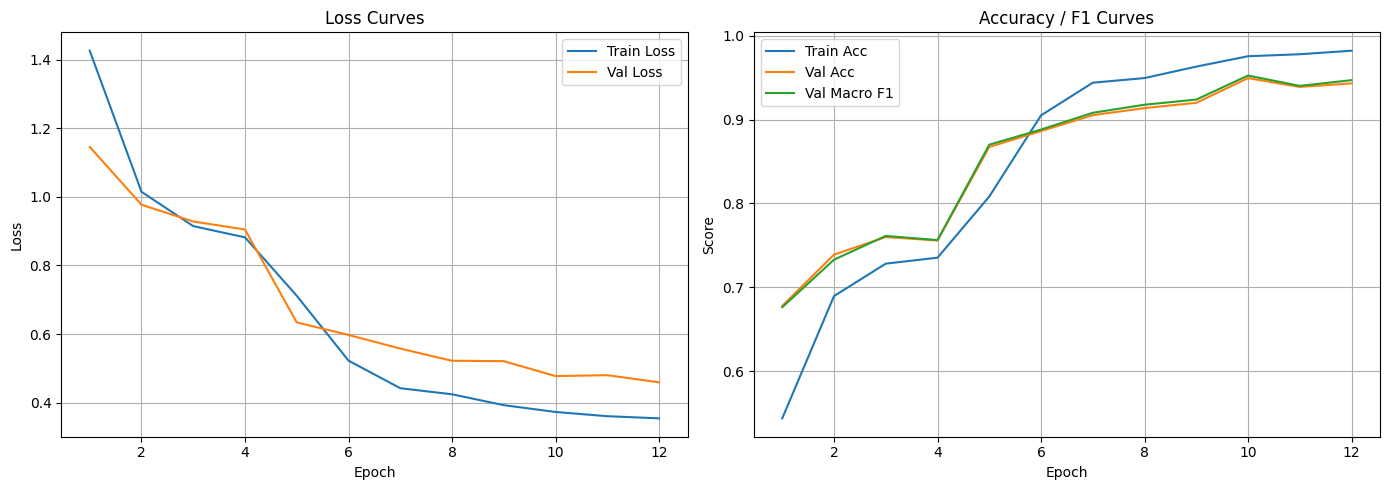

In [24]:

if 'best_history' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(best_history['epoch'], best_history['train_loss'], label='Train Loss')
    axes[0].plot(best_history['epoch'], best_history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(best_history['epoch'], best_history['train_acc'], label='Train Acc')
    axes[1].plot(best_history['epoch'], best_history['val_acc'], label='Val Acc')
    axes[1].plot(best_history['epoch'], best_history['val_f1'], label='Val Macro F1')
    axes[1].set_title('Accuracy / F1 Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 18. Final evaluation on the test set

Do this **only after** choosing your final model using the validation set.
That keeps the test set honest.

In [25]:

criterion_for_eval = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.0)

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    best_model, test_loader, criterion_for_eval, DEVICE
)

print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Macro F1:  {test_f1:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

Test Loss:      0.2889
Test Accuracy:  0.9181
Test Macro F1:  0.9209


In [26]:

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True,
)
report_df = pd.DataFrame(report).transpose()
display(report_df)

,precision,recall,f1-score,support
Cardboard,0.914894,0.934783,0.924731,46.000000
Food Organics,0.975610,0.975610,0.975610,41.000000
Glass,0.947368,0.857143,0.900000,42.000000
Metal,0.935065,0.911392,0.923077,79.000000
Miscellaneous Trash,0.902439,0.740000,0.813187,50.000000
Paper,0.959184,0.940000,0.949495,50.000000
Plastic,0.854369,0.946237,0.897959,93.000000
Textile Trash,0.864865,1.000000,0.927536,32.000000
Vegetation,0.976744,0.976744,0.976744,43.000000
accuracy,0.918067,0.918067,0.918067,0.918067


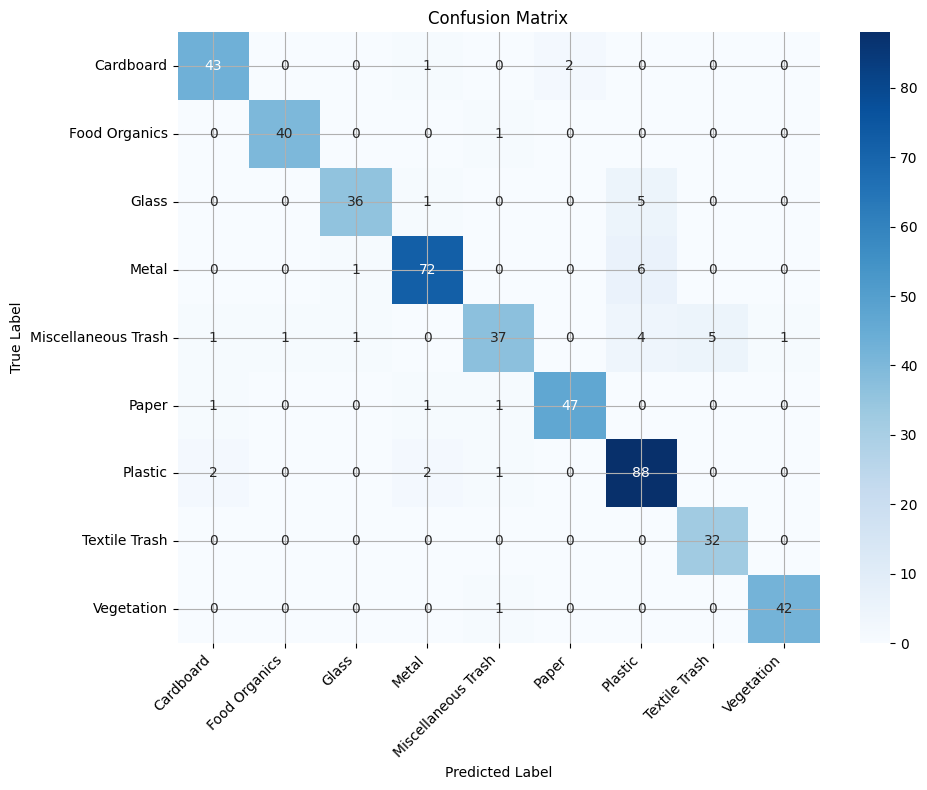

In [27]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### How to interpret the confusion matrix

This is one of the most important analysis tools for your report.

Look for questions like:
- Does **Paper** get confused with **Cardboard**?
- Does **MiscellaneousTrash** absorb difficult examples from other classes?
- Are organic-looking classes such as **FoodOrganics** and **Vegetation** getting mixed up?

This gives you ideas for future improvements:
- more examples,
- cleaner labels,
- stronger augmentation,
- larger image size,
- better class definitions,
- or eventually object detection if clutter/background is causing errors.

## 19. Show sample predictions

Seeing correct and incorrect examples is extremely useful for learning *why* the model behaves the way it does.

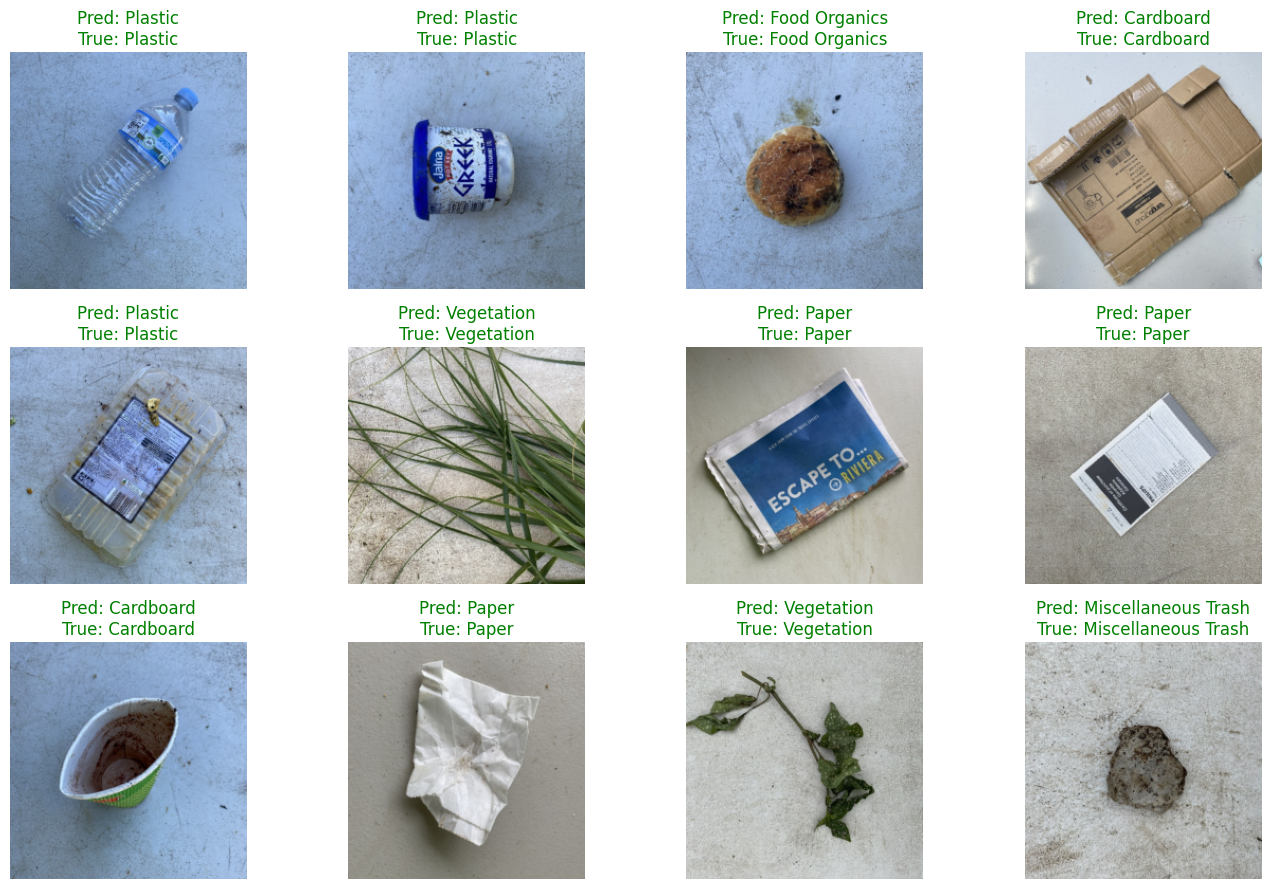

In [29]:

@torch.no_grad()
def show_predictions(model, loader, idx_to_class, device=DEVICE, max_images=12):
    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()

    fig, axes = plt.subplots(math.ceil(max_images / 4), 4, figsize=(14, 3 * math.ceil(max_images / 4)))
    axes = np.array(axes).reshape(-1)

    for i in range(max_images):
        img = denormalize(images[i].cpu()).clamp(0, 1)
        axes[i].imshow(img.permute(1, 2, 0))
        true_name = idx_to_class[int(labels[i])]
        pred_name = idx_to_class[int(preds[i])]
        color = 'green' if true_name == pred_name else 'red'
        axes[i].set_title(f"Pred: {pred_name}\nTrue: {true_name}", color=color)
        axes[i].axis('off')

    for ax in axes[max_images:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(best_model, test_loader, idx_to_class)

## 20. Save the best model and experiment results

This is helpful for your final report, final presentation, and later deployment work.

In [30]:

OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

best_model_path = OUTPUT_DIR / 'best_realwaste_model.pt'
torch.save(best_model.state_dict(), best_model_path)
print('Saved model to:', best_model_path.resolve())

if 'best_history' in globals():
    best_history.to_csv(OUTPUT_DIR / 'best_history.csv', index=False)

if 'comparison_df' in globals():
    comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)

report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')

summary = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_acc),
    'test_macro_f1': float(test_f1),
    'class_names': class_names,
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'device': str(DEVICE),
}

with open(OUTPUT_DIR / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved outputs to:', OUTPUT_DIR.resolve())

Saved model to: /Users/juliareinhart/Documents/CSCI611AppliedMachineLearning/BranchJuliaFinalProject/outputs/best_realwaste_model.pt
Saved outputs to: /Users/juliareinhart/Documents/CSCI611AppliedMachineLearning/BranchJuliaFinalProject/outputs


## 21. Experiment notes template for your report

Use this section to record what changed and whether it helped.

A strong final report usually includes an ablation-style table like this:

| Experiment | Change | Why we tried it | Val Accuracy | Val Macro F1 | Result |
|---|---|---|---:|---:|---|
| Baseline | EfficientNet-B0, resize 224, no weighted loss | strong transfer baseline | ... | ... | baseline |
| Exp 2 | Added stronger augmentation | reduce overfitting | ... | ... | helped / did not help |
| Exp 3 | Added weighted sampler + class weights | address imbalance | ... | ... | helped / did not help |
| Exp 4 | Switched to EfficientNet-B2 | larger backbone | ... | ... | helped / did not help |
| Exp 5 | Increased image size | capture more detail | ... | ... | helped / did not help |

### What usually helps on this dataset
Most likely helpful:
- transfer learning,
- careful augmentation,
- stronger backbone,
- class imbalance handling,
- fine-tuning after frozen-head training,
- confusion-matrix-driven error analysis.

### What might not help
Sometimes these hurt performance:
- augmentation that is too aggressive,
- too many epochs with no early stopping,
- training from scratch,
- too large a learning rate,
- vertical flips if they make images unrealistic,
- evaluating many settings without keeping the split fixed.

## 22. Accuracy improvement ideas to try next

Try these one at a time so you know what caused the improvement.

### Strong next experiments
1. **Increase image size** from 224 to 260 or 288  
2. **Train longer** with patience increased slightly  
3. **Try EfficientNet-B2 vs B0 carefully**  
4. **Test with and without class weights**  
5. **Test with and without weighted sampler**  
6. **Tune augmentation strength**  
7. **Try label smoothing = 0.0, 0.05, 0.1**  
8. **Add test-time augmentation (TTA)** if you want an advanced improvement  
9. **Clean the labels** for difficult categories like MiscellaneousTrash  
10. **Merge / redefine ambiguous labels only if justified by the confusion matrix**

### Important project insight
If your biggest errors come from:
- cluttered scenes,
- multiple objects,
- object location confusion,

then that is a sign classification may be hitting its limit and **YOLO/object detection** becomes the logical next step.

## 23. Optional: advanced augmentation ideas

You do **not** need these on day one, but they are useful later.

- **MixUp**: blends two training images and labels
- **CutMix**: pastes part of one image into another
- **Random Erasing**: forces robustness to missing regions

These can improve generalization, but they also make the notebook more complex.
I recommend getting a strong clean baseline first, then testing these only after you have a stable pipeline.

## 24. How this connects to YOLO later

Your uploaded YOLO notebook shows the beginning of the next stage, but YOLO solves a different problem.

### Classification vs. YOLO
- **Classification**: predicts one label for the whole image.
- **YOLO detection**: predicts one or more objects plus bounding boxes.

### Why classification first is still the right move
This notebook helps you answer:
- Which classes are hardest?
- Which classes are visually similar?
- Is background clutter hurting performance?
- Is label ambiguity a problem?

Those answers tell you whether YOLO is worth the extra labeling effort.

### For the future YOLO step
You will need:
- images,
- bounding-box annotations,
- train/val split in YOLO format,
- object-detection metrics such as mAP.

## 25. Final recommendations

If your goal is **highest practical accuracy** for the first serious version of this project, my recommendation is:

1. Start with **EfficientNet-B0** as a fast strong baseline.  
2. Then try **EfficientNet-B2** for a possible accuracy improvement.  
3. Keep the **same stratified split** for every experiment.  
4. Record every change in a results table.  
5. Use the confusion matrix to decide what to improve next.  
6. Only move to YOLO after the classification pipeline is well understood.

That gives you a clean project story for your report and presentation:
- baseline,
- improvements,
- analysis,
- final best model,
- future object detection plan.